# **Multilayer Percerptron Networks**
  (Keras and Tensorflow implementation)

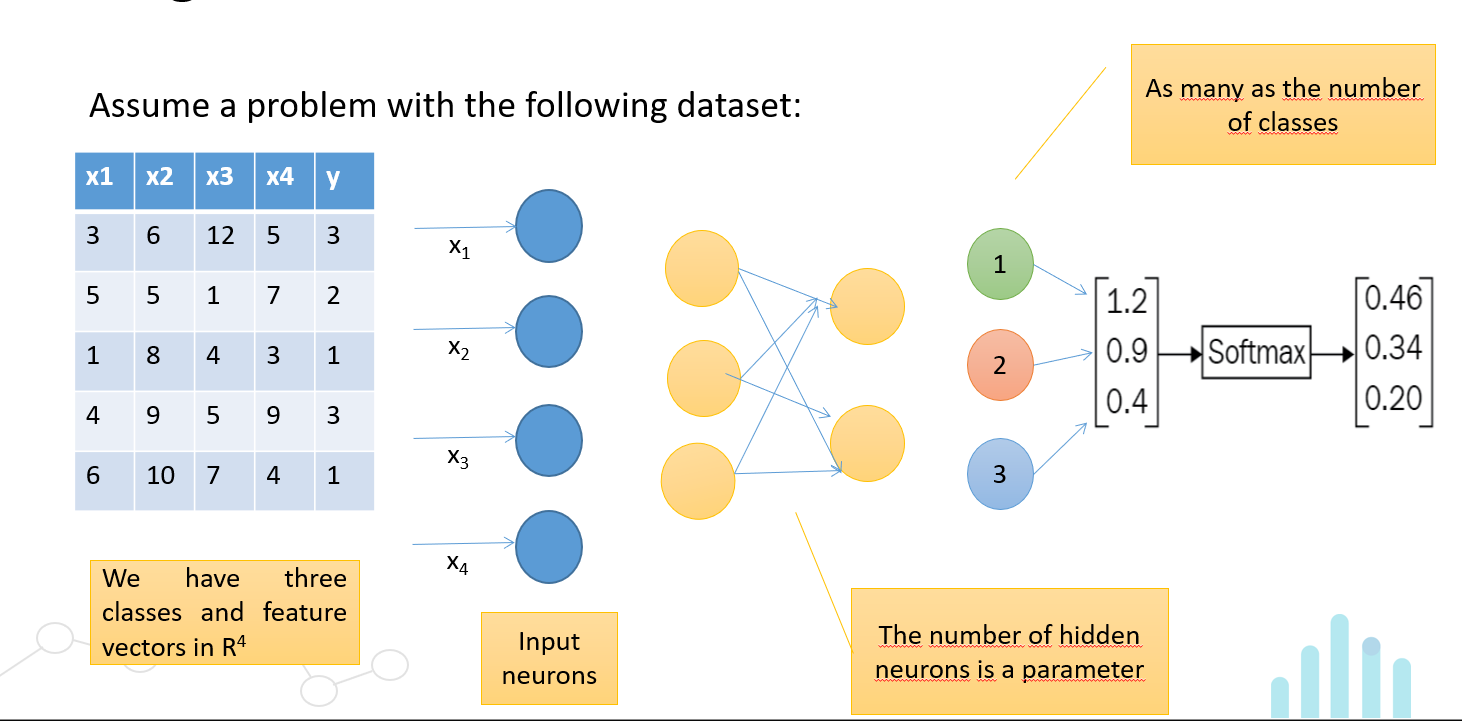

**Librerias base para redes neuronales**

In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import datasets


**Cargar datos**

In [8]:
X, y = datasets.load_iris(return_X_y=True, as_frame=True)
y.unique()

array([0, 1, 2])

**Features**

In [9]:
#Propiedades de flores
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
print("Cantidad de flores:"+str(len(X)))

Cantidad de flores:150


**Classes**

In [11]:
# Y guarda las clases de flores
y.unique() #Las clases existentes

array([0, 1, 2])

**Separacion de datos en entrenamiento (train) y prueba (test)**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [13]:
print("Cantidad de flores para entrenamiento:"+str(len(X_train)))

Cantidad de flores para entrenamiento:120


**Diseño de la red neuronal**

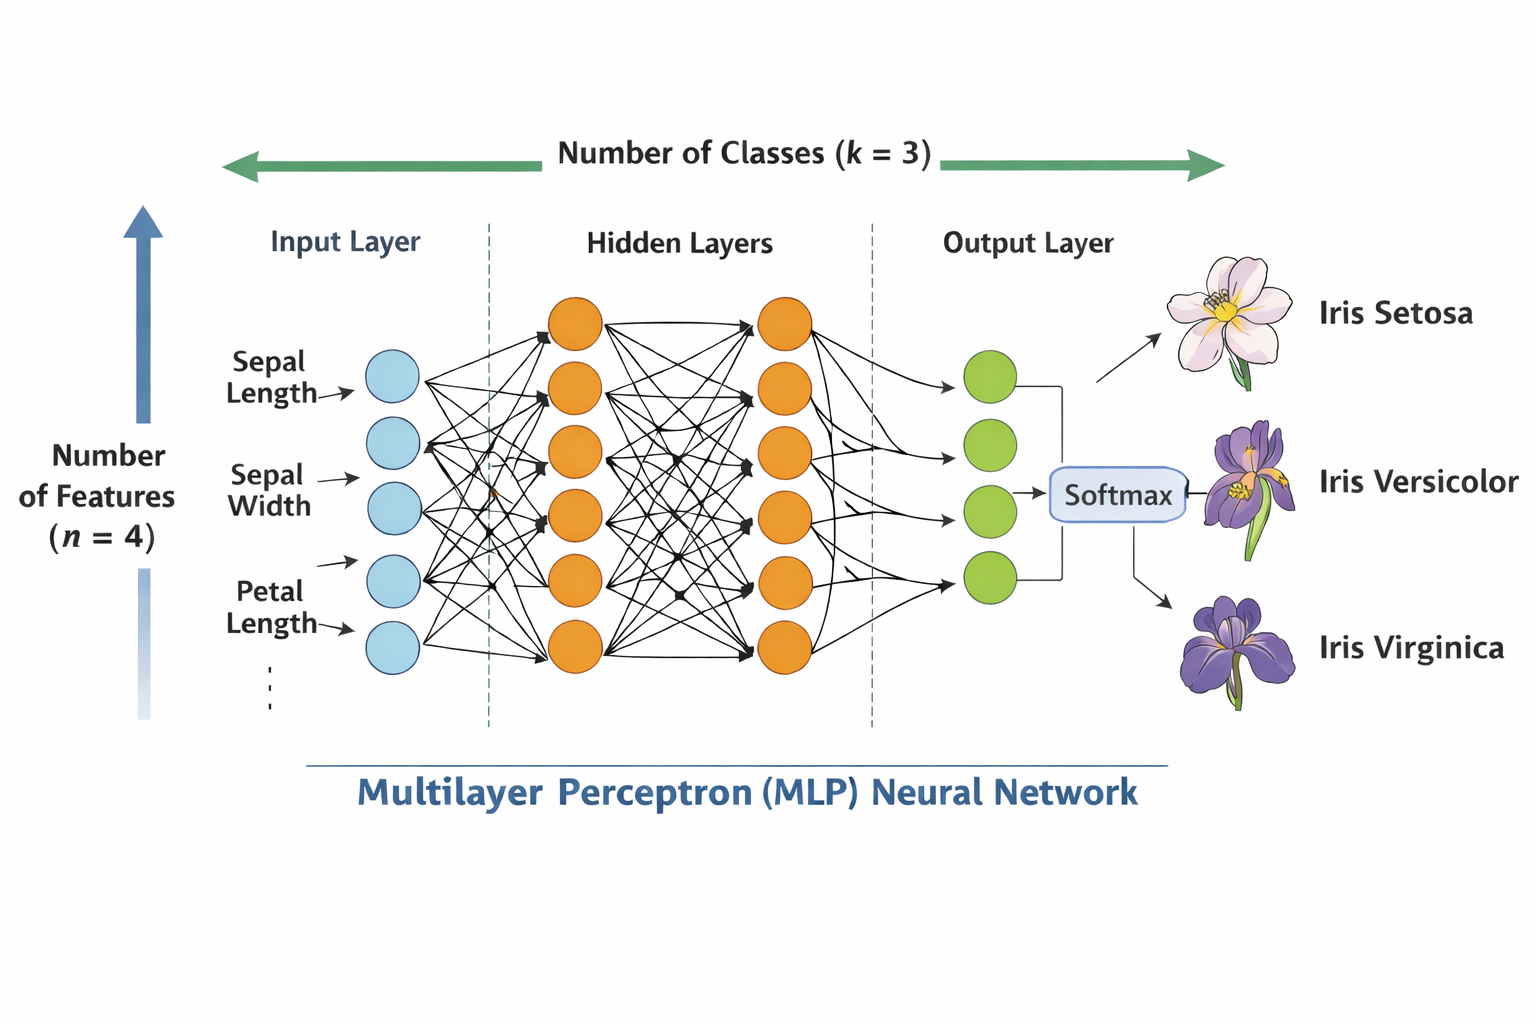

In [14]:
# First, we initialize the model.
model = tf.keras.models.Sequential()

In [15]:
# First our input layer. For this layer, and this layer only, we need to specify the size of our input. For our dataset this means the amount of columns in our X.
model.add(tf.keras.layers.Dense(4, activation=tf.nn.tanh, input_shape=(X.shape[1],)))
# Now some hidden layers
model.add(tf.keras.layers.Dense(8, activation=tf.nn.tanh))
model.add(tf.keras.layers.Dense(16, activation=tf.nn.tanh))
# Finally, our output layer. Since we have 3 possible classes, we need 3 output neurons.
# For a regression problem, we would have only 1. For an image creation network, we would have as many pixels as the image we wanted to create!
model.add(tf.keras.layers.Dense(3))
# A final layer with several output neurons gives us logits as results.
#We can do a final pass with a Softmax layer to turn them into percentages.
model.add(tf.keras.layers.Softmax())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
optim = tf.keras.optimizers.Adam(learning_rate=0.01)

In [17]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=optim,metrics=['accuracy'])


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255 (1020.00 B)

 Trainable params: 255 (1020.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(X_train.values, y_train.values,
        validation_data=(X_test.values, y_test.values),
        epochs = 50,
        batch_size=120)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.1187 - val_accuracy: 0.3000 - val_loss: 1.1107
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3417 - loss: 1.0991 - val_accuracy: 0.3000 - val_loss: 1.0992
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3417 - loss: 1.0918 - val_accuracy: 0.3000 - val_loss: 1.0908
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3417 - loss: 1.0878 - val_accuracy: 0.3667 - val_loss: 1.0829
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3250 - loss: 1.0824 - val_accuracy: 0.3667 - val_loss: 1.0728
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3250 - loss: 1.0723 - val_accuracy: 0.3667 - val_loss: 1.0594
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3750 - loss: 1.0571 - val_accuracy: 0.5333 - val_loss: 1.0425
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5917 - loss: 1.0372 - val_accuracy: 0.7000 - val_loss: 1.0217


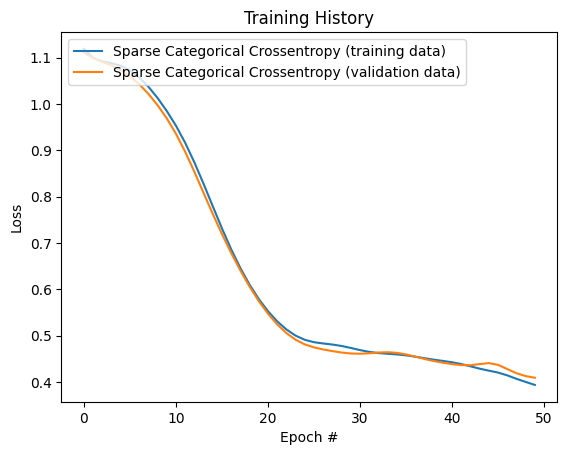

In [21]:
plt.plot(history.history['loss'], label='Sparse Categorical Crossentropy (training data)')
plt.plot(history.history['val_loss'], label='Sparse Categorical Crossentropy (validation data)')
plt.title('Training History')
plt.ylabel('Loss')
plt.xlabel('Epoch #')
plt.legend(loc="upper left")
plt.show()


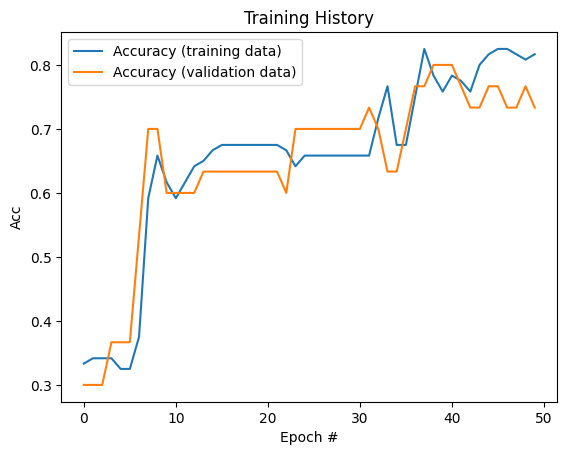

In [22]:
plt.plot(history.history['accuracy'], label='Accuracy (training data)')
plt.plot(history.history['val_accuracy'], label='Accuracy (validation data)')
plt.title('Training History')
plt.ylabel('Acc')
plt.xlabel('Epoch #')
plt.legend(loc="upper left")
plt.show()

In [23]:
#10: Ver el desempeño
predictions = model.predict(X_test)
y_pred=[]
for idx, prediction in enumerate(predictions):
  y_pred.append(np.argmax(prediction))
  print('We predict: '+str(y_pred[idx])+'. Real Species was: '+str(y_test.iloc[idx]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
We predict: 2. Real Species was: 1
We predict: 0. Real Species was: 0
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 1
We predict: 2. Real Species was: 1
We predict: 0. Real Species was: 0
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 2
We predict: 2. Real Species was: 1
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 1. Real Species was: 1
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 1
We predict: 2. Real Species was: 1
We predict: 2. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 1. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 2. Real Species was: 2
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 2
We predict: 2. Real Species was: 2
We predict: 2. R

0.7333333333333333

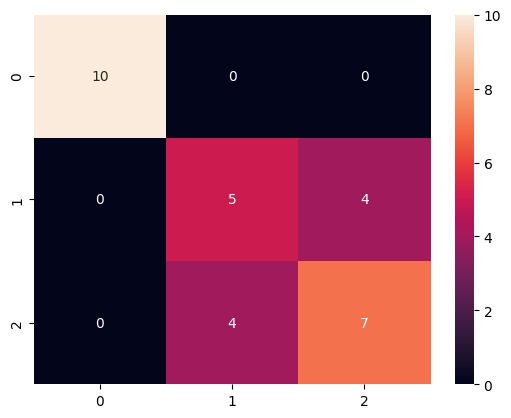

In [24]:
#Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm
#Plot heat map
import seaborn as sns
sns.heatmap(cm, annot=True)
#Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)



# **Non-linear separable problems**

**Circles**

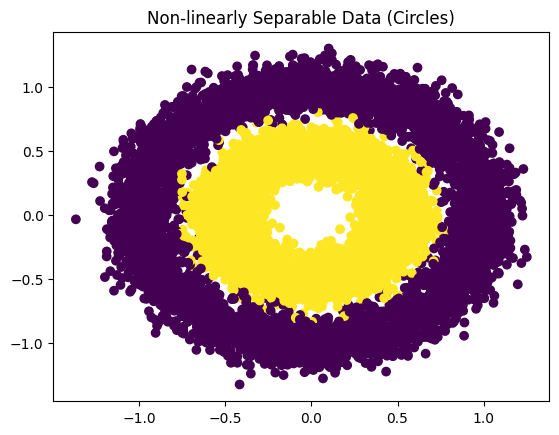

In [26]:
#Generate a non-linear separable set

from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Generate data
X, y = make_circles(n_samples=10000, noise=0.1, factor=0.5, random_state=42)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linearly Separable Data (Circles)")
plt.show()

In [27]:
#Design a minimal Neural Network

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(2, activation=tf.nn.tanh, input_shape=(X.shape[1],)))#input layer
model.add(tf.keras.layers.Dense(8, activation=tf.nn.tanh))#Hidden layer
model.add(tf.keras.layers.Dense(8, activation=tf.nn.tanh))
model.add(tf.keras.layers.Dense(1))# Output layer
model.add(tf.keras.layers.Activation('sigmoid'))

optim = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=optim,metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#train model
history = model.fit(X_train, y_train,
        validation_data=(X_test, y_test),
        epochs = 50,
        batch_size=120)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6584 - loss: 0.6519 - val_accuracy: 0.7358 - val_loss: 0.5691
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7528 - loss: 0.5254 - val_accuracy: 0.7676 - val_loss: 0.4955
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7742 - loss: 0.4805 - val_accuracy: 0.7688 - val_loss: 0.4710
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8048 - loss: 0.4395 - val_accuracy: 0.8027 - val_loss: 0.4338
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8143 - loss: 0.3944 - val_accuracy: 0.8048 - val_loss: 0.3848
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8316 - loss: 0.3628 - val_accuracy: 0.8479 - val_loss: 0.3623
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8552 - loss: 0.3425 - val_accuracy: 0.8470 - val_loss: 0.3483
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8624 - loss: 0.3103 - val_accuracy: 0.8579 - val_loss:

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

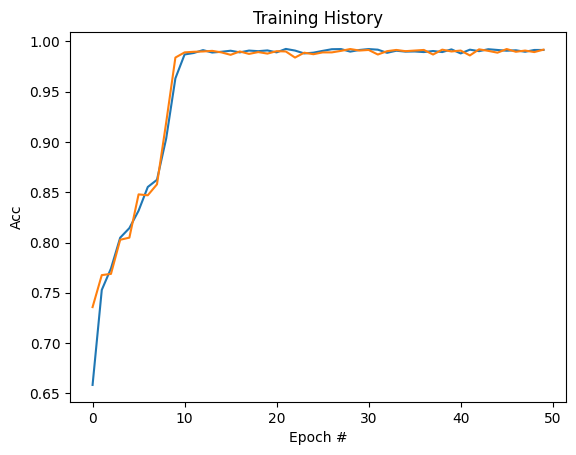

In [29]:
#plot accuracy and val_accuracy
plt.plot(history.history['accuracy'], label='Accuracy (training data)')
plt.plot(history.history['val_accuracy'], label='Accuracy (validation data)')
plt.title('Training History')
plt.ylabel('Acc')
plt.xlabel('Epoch #')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

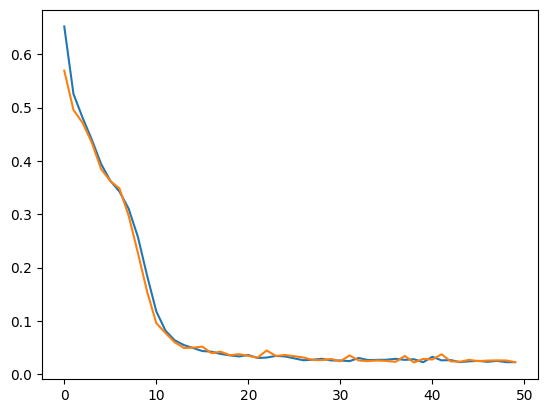

In [30]:
#plot loss
plt.plot(history.history['loss'], label=' Crossentropy (training data)')
plt.plot(history.history['val_loss'], label=' Crossentropy (validation data)')
plt

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


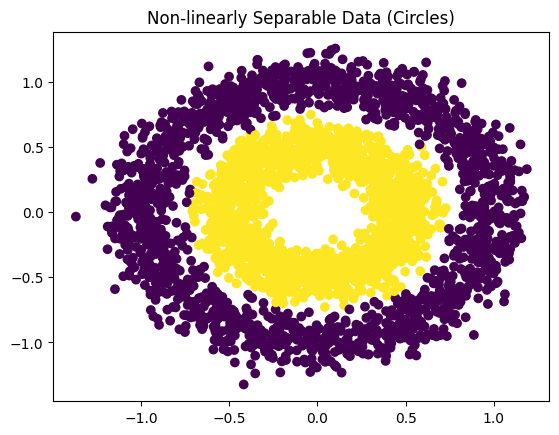

In [31]:
#plot test classification
import numpy as np
import matplotlib.pyplot as plt

y_pred=[]
for idx, prediction in enumerate(model.predict(X_test)):
  y_pred.append(np.round(prediction))

#plot data and predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.title("Non-linearly Separable Data (Circles)")
plt.show()

**Moons**

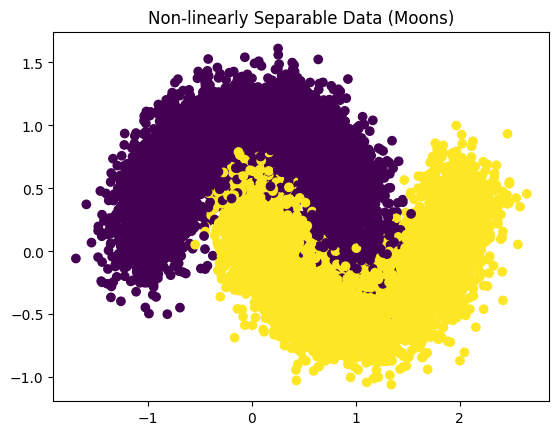

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=10000, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linearly Separable Data (Moons)")
plt.show()

**Exercise:** Design a Multilayer Perceptron Network to solve this non-linear separable problem.

**1. Split dataset**

In [ ]:
#Your code here

**2. Design MLPN**

In [ ]:
#Your code here

**3. Train model**

In [ ]:
#Your code here

**4. Plot the training metrics (accuracy and loss function)**

In [ ]:
#Your code here

**5. Inference using the test data**

In [ ]:
#Your code here

**6. Evaluate the prediction**

In [ ]:
#Your code here